# Vanishing gradients, and what they cost you

**Talk 1, interlude.**

The claim from the slides was that gradients decay exponentially with distance. 

We show it in two steps:

1. **Measure** how much gradient survives the trip back through time.
2. **Train** the same models and watch accuracy collapse *exactly where the gradient dies*.

No downloads needed.

In [1]:
import torch, torch.nn as nn, math, time, json, os
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

FAST = False          # True: ~2 min total. False: adds L=64, ~6 min.
CACHE = "results.json"

device: cuda | torch 2.10.0


---
## The task: needle-in-a-haystack recall

Synthetic on purpose. A real dataset would confound *architecture* with *data*; we want exactly
one variable: **how far back must the model reach?**

Random tokens, one `MARKER` dropped at a **random** position. The model must output the token
immediately after the marker, and may only answer at the very end.

```
tokens:  7  3  12  [MARKER]  9  4  1  ...  6  [QUERY]
                       ^     ^
                    marker  answer = 9
```

Random placement is the crucial detail — it kills any positional shortcut, so the model must
search by **content**. And $L$ controls the distance, which is the thing we sweep.

In [2]:
V, MARKER, QUERY, VOCAB, NCLS = 16, 16, 17, 18, 16
CHANCE = 1 / NCLS

def make_batch(B, L, device="cpu"):
    seq = torch.randint(0, V, (B, L), device=device)
    p   = torch.randint(0, L - 1, (B,), device=device)
    tgt = seq[torch.arange(B), p + 1].clone()
    seq[torch.arange(B), p] = MARKER
    seq = torch.cat([seq, torch.full((B, 1), QUERY, device=device)], dim=1)
    return seq, tgt, p

x, y, p = make_batch(1, 16)
print("sequence:", x[0].tolist())
print("marker at position", p.item(), "-> answer is", y.item())
print("chance accuracy =", CHANCE)

sequence: [12, 15, 5, 0, 3, 11, 16, 7, 9, 3, 5, 2, 4, 7, 6, 8, 17]
marker at position 6 -> answer is 7
chance accuracy = 0.0625


---
## The models

Three architectures, matched in size. The recurrent models get **more** hidden width, so nobody
can say the transformer won on parameter count.

In [3]:
class Recurrent(nn.Module):
    def __init__(self, kind="lstm", d=128):
        super().__init__()
        self.emb  = nn.Embedding(VOCAB, d)
        self.rnn  = (nn.LSTM if kind == "lstm" else nn.RNN)(d, d, batch_first=True)
        self.head = nn.Linear(d, NCLS)
    def forward(self, x, keep=False):
        h, _ = self.rnn(self.emb(x))
        return self.head(h[:, -1]), None

class Block(nn.Module):
    def __init__(self, d, nhead, ff):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, nhead, batch_first=True)
        self.ff   = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d))
    def forward(self, x, keep=False):
        h = self.n1(x)
        a, w = self.attn(h, h, h, need_weights=keep, average_attn_weights=True)
        x = x + a                              # attention writes into the residual stream
        return x + self.ff(self.n2(x)), w      # ...then the FFN does

class Transformer(nn.Module):
    def __init__(self, d=64, nhead=4, layers=2, ff=256, maxlen=1024):
        super().__init__()
        self.emb, self.pos = nn.Embedding(VOCAB, d), nn.Embedding(maxlen, d)
        self.blocks = nn.ModuleList([Block(d, nhead, ff) for _ in range(layers)])
        self.nf, self.head = nn.LayerNorm(d), nn.Linear(d, NCLS)
    def forward(self, x, keep=False):
        h = self.emb(x) + self.pos(torch.arange(x.shape[1], device=x.device))[None]
        ws = []
        for b in self.blocks:
            h, w = b(h, keep); ws.append(w)
        return self.head(self.nf(h)[:, -1]), ws

MODELS = {"vanilla RNN": lambda: Recurrent("rnn"),
          "LSTM":        lambda: Recurrent("lstm"),
          "Transformer": lambda: Transformer()}

nparams = lambda m: sum(q.numel() for q in m.parameters())
for nm, f in MODELS.items():
    print(f"{nm:14s} {nparams(f()):>8,d} parameters")

vanilla RNN      37,392 parameters
LSTM            136,464 parameters
Transformer     167,824 parameters


---
# Step 1 — Measure the gradient

Run each model over a length-60 sequence, take the loss at the **last** position, call
`.backward()`, and record the gradient norm arriving at **every** timestep.

No training needed — this is a property of the architecture at initialisation.
Read it as: *how much does the loss still care about what happened at step t?*

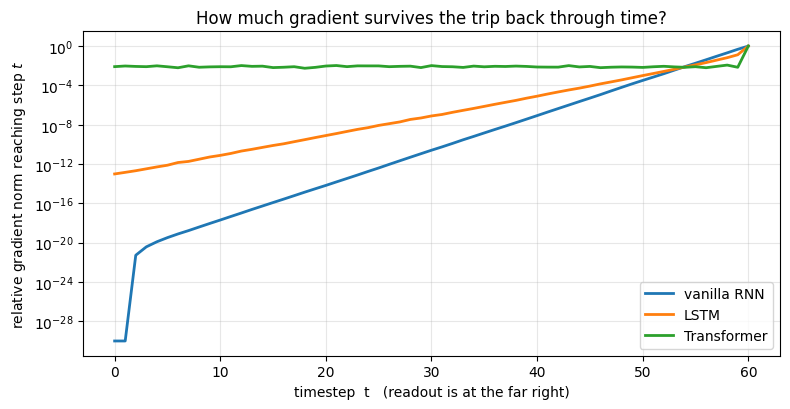

vanilla RNN     t=0: 0.00e+00   t=30: 2.54e-11   t=59: 4.70e-01
LSTM            t=0: 9.81e-14   t=30: 7.80e-08   t=59: 1.31e-01
Transformer     t=0: 8.10e-03   t=30: 1.03e-02   t=59: 6.98e-03


In [4]:
def grad_profile_recurrent(kind, L=60, d=64, B=64):
    emb  = nn.Embedding(VOCAB, d)
    cell = (nn.LSTMCell if kind == "lstm" else nn.RNNCell)(d, d)
    head = nn.Linear(d, NCLS)
    x, y, _ = make_batch(B, L); e = emb(x)
    h = torch.zeros(B, d); c = torch.zeros(B, d); hs = []
    for t in range(e.shape[1]):
        if kind == "lstm": h, c = cell(e[:, t], (h, c))
        else:              h    = cell(e[:, t], h)
        h.retain_grad(); hs.append(h)
    nn.CrossEntropyLoss()(head(hs[-1]), y).backward()
    return torch.tensor([hh.grad.norm().item() for hh in hs])

def grad_profile_transformer(L=60, B=64):
    m = Transformer(); x, y, _ = make_batch(B, L)
    e = (m.emb(x) + m.pos(torch.arange(x.shape[1]))[None]).detach().requires_grad_(True)
    h = e
    for b in m.blocks: h, _ = b(h)
    nn.CrossEntropyLoss()(m.head(m.nf(h)[:, -1]), y).backward()
    return e.grad.norm(dim=(0, 2))

profiles = {"vanilla RNN": grad_profile_recurrent("rnn"),
            "LSTM":        grad_profile_recurrent("lstm"),
            "Transformer": grad_profile_transformer()}

plt.figure(figsize=(8, 4.2))
for nm, g in profiles.items():
    plt.semilogy((g / g.max()).clamp(min=1e-30).numpy(), lw=2, label=nm)
plt.xlabel("timestep  t   (readout is at the far right)")
plt.ylabel("relative gradient norm reaching step $t$")
plt.title("How much gradient survives the trip back through time?")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

for nm, g in profiles.items():
    g = g / g.max()
    print(f"{nm:14s}  t=0: {g[0]:.2e}   t=30: {g[30]:.2e}   t=59: {g[59]:.2e}")

---
# Step 2 — Now watch it cost accuracy

We train all three at increasing sequence length and measure accuracy. The prediction from Step 1
is specific: the vanilla RNN, whose gradient underflows to zero past ~30 steps, should **fail to
learn at all** once the marker sits further back than that.

vanilla RNN    L=  8  acc=1.000   (6s)
vanilla RNN    L= 16  acc=1.000   (2s)
vanilla RNN    L= 32  acc=0.544   (2s)
vanilla RNN    L= 64  acc=0.070   (3s)
LSTM           L=  8  acc=1.000   (1s)
LSTM           L= 16  acc=1.000   (1s)
LSTM           L= 32  acc=1.000   (1s)
LSTM           L= 64  acc=1.000   (3s)
Transformer    L=  8  acc=1.000   (4s)
Transformer    L= 16  acc=1.000   (5s)
Transformer    L= 32  acc=1.000   (14s)
Transformer    L= 64  acc=1.000   (20s)


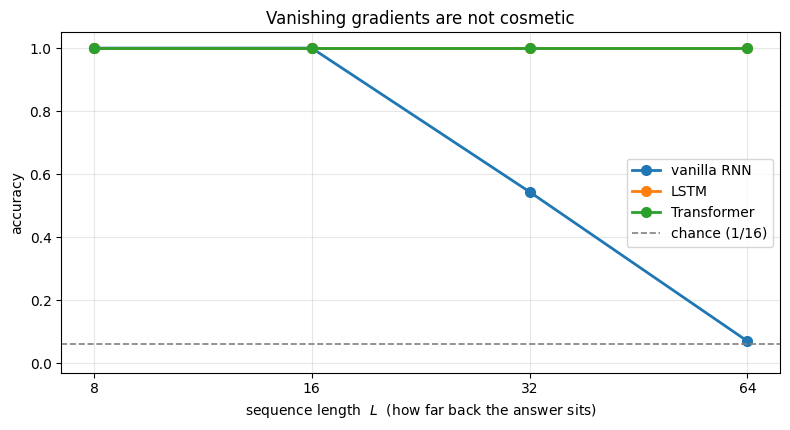

In [8]:
def train(model, L, steps, B=64, lr=2e-3, warmup=100, patience=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, (s + 1) / warmup))
    lf, hist = nn.CrossEntropyLoss(), []
    for s in range(steps):
        x, y, _ = make_batch(B, L, device)
        loss = lf(model(x)[0], y)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step(); hist.append(loss.item())
        if loss.item() < patience: break        # early exit once solved
    return hist

@torch.no_grad()
def accuracy(model, L, n=1024, B=256):
    model.eval(); cs = []
    for _ in range(n // B):
        x, y, _ = make_batch(B, L, device)
        cs.append((model(x)[0].argmax(-1) == y).float())
    model.train(); return torch.cat(cs).mean().item()

LENGTHS = [8, 16, 32] if FAST else [8, 16, 32, 64]
BUDGET  = {"vanilla RNN": 800, "LSTM": 800, "Transformer": 2500 if FAST else 5000}


results = {nm: [] for nm in MODELS}
for nm, factory in MODELS.items():
    for L in LENGTHS:
        m = factory(); t0 = time.time()
        train(m, L, BUDGET[nm]); a = accuracy(m, L)
        results[nm].append(a)
        print(f"{nm:14s} L={L:3d}  acc={a:.3f}   ({time.time()-t0:.0f}s)", flush=True)
        if nm == "Transformer" and L == LENGTHS[-1]: trained_tf, trained_L = m, L
json.dump(results, open(CACHE, "w"))

plt.figure(figsize=(8, 4.4))
for nm in MODELS:
    plt.plot(LENGTHS, results[nm], "o-", lw=2, ms=7, label=nm)
plt.axhline(CHANCE, ls="--", c="gray", lw=1.2, label="chance (1/16)")
plt.xlabel("sequence length  $L$  (how far back the answer sits)")
plt.ylabel("accuracy"); plt.ylim(-0.03, 1.05); plt.xscale("log", base=2)
plt.xticks(LENGTHS, [str(l) for l in LENGTHS])
plt.title("Vanishing gradients are not cosmetic")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()